# Module 6 — Day 1 Breakout: Decision Trees on the Moons Dataset
## PHY 657, Spring 2026

---

Work with your partner. You have ~10 minutes.

The "moons" dataset is two interleaving half-circles — a classic non-linearly-separable problem.

### Tasks

1. Fit a `DecisionTreeClassifier` with `max_depth=2`. Plot the decision boundary and report train/test accuracy.
2. Repeat with `max_depth=10` and `max_depth=None` (unlimited).
3. Use `plot_tree` to visualize the depth-2 tree. How many splits does it make? Can you describe the decision logic in plain English?
4. Fit a `LogisticRegression` on the same data. Which does better?

**Discussion question:** In what situations would you prefer the tree over logistic regression, even if it has lower accuracy?

---
## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'font.size': 14, 'figure.figsize': (8, 6)})

cmap_bg = ListedColormap(['#AEDDFF', '#FFCCCC'])
cmap_pts = ListedColormap(['tab:blue', 'tab:red'])

Train: 280, Test: 120


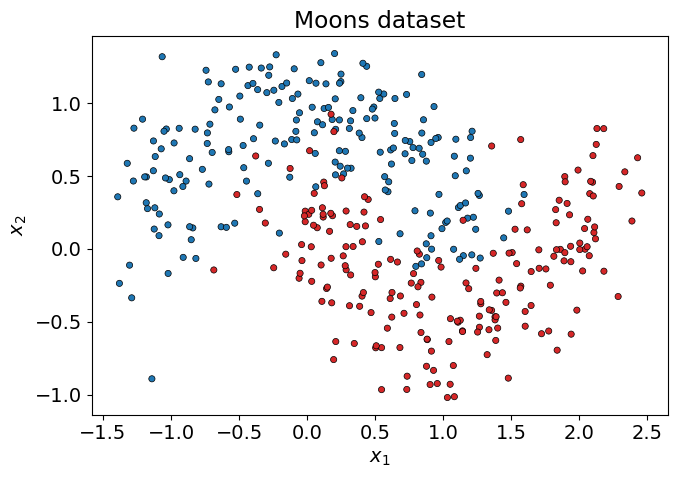

In [2]:
# Generate the dataset
X, y = make_moons(n_samples=400, noise=0.25, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y
)

print(f'Train: {len(y_train)}, Test: {len(y_test)}')


fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_pts, edgecolors='k', s=20, linewidths=0.5)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('Moons dataset')
plt.tight_layout()
plt.show()

In [3]:
# Helper function for plotting decision boundaries
def plot_decision_boundary(model, X_train, y_train, X_test, y_test, ax, title=''):
    xx, yy = np.meshgrid(
        np.linspace(X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5, 300),
        np.linspace(X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5, 300),
    )
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_bg)
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cmap_pts,
              edgecolors='k', s=15, linewidths=0.3, label='train')
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=cmap_pts,
              edgecolors='k', s=40, linewidths=0.5, marker='s', alpha=0.5, label='test')
    tr_acc = model.score(X_train, y_train)
    te_acc = model.score(X_test, y_test)
    ax.set_title(f'{title}\ntrain: {tr_acc:.1%}, test: {te_acc:.1%}')
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')

---
## Task 1 & 2: Fit trees at different depths

Fit `DecisionTreeClassifier` with `max_depth` = 2, 10, and `None`. Plot the decision boundary for each using the helper function above.

In [ ]:
# YOUR CODE HERE
# Hint: create a figure with 1 row, 3 columns
#   fig, axes = plt.subplots(1, 3, figsize=(18, 5))
#   for each depth, fit a tree, then call plot_decision_boundary(...)



---
## Task 3: Visualize the depth-2 tree

Use `plot_tree` to draw the full tree structure for the `max_depth=2` tree.

Questions to answer:
- How many splits does it make?
- What features and thresholds does it use?
- Can you describe the decision logic in words? (e.g., "If $x_2 > 0.3$ and $x_1 < 0.5$, classify as ...")

In [ ]:
# YOUR CODE HERE
# Hint: 
#   fig, ax = plt.subplots(figsize=(14, 7))
#   plot_tree(your_tree, feature_names=['x1', 'x2'], class_names=['Class 0', 'Class 1'],
#             filled=True, rounded=True, ax=ax)



**Write your description of the decision logic here:**

(double-click to edit)


---
## Task 4: Compare with logistic regression

Fit a `LogisticRegression()` and plot its boundary alongside the depth-2 tree.

In [ ]:
# YOUR CODE HERE
# Hint: fit LogisticRegression, then use plot_decision_boundary



---
## Discussion

**In what situations would you prefer the tree over logistic regression, even if it has lower accuracy?**

Think about:
- When is interpretability more important than accuracy?
- What does the logistic regression boundary look like on this data? Why?
- If you had to explain your classifier to a collaborator who is not a machine learning expert, which would be easier to explain?

(Write your thoughts here — we will discuss as a class)
